In [2]:
pip install polars matplotlib typing_extensions==4.11.0 great_tables numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 23.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.6/111.6 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 86.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 66.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 178.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 175.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 165.6 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 7.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 241.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 50.3 MB/s eta 0:00:00


In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from great_tables import GT, style, loc
from collections import defaultdict
from dataclasses import dataclass
from enum import Enum

# Utilities

In [84]:
schema = pl.Schema({"Timers":pl.UInt64(), "TxTime":pl.UInt64(), "RxTime":pl.UInt64()})

class Library(Enum):
    libfabric = "libfabric"
    native = "native"
    ucx = "ucx"

class Format(Enum):
    _720= "720"
    _1080= "1080"
    _2160= "2160"

class Completion(Enum):
    spin = "Spin"
    wait = "Wait"
    none = ""
    
class Transport(Enum):
    tcp = "Tcp"
    verbs = "Verbs"
    shm = "SHM"
    none = ""

class TransferMode(Enum):
    oneway = "OneWay"
    reflect = "Reflect"
    none = ""

class Movement(Enum):
    d2d = "Cuda2Cuda"
    dh2hd = "Cuda2Host2Host2Cuda"
    h2d = "Host2Cuda"
    d2h = "Cuda2Host"

    def to_study_name(self) -> str:
        match self:
            case Movement.d2d:
                return "Device-to-Device"
            case Movement.dh2hd:
                return "Device-to-Host-to-Host-to-Device"
            case Movement.h2d:
                return "Host-to-Device"
            case Movement.d2h:
                return "Device-to-Host"
    
class Test(Enum):
    mxl_fabrics="MXLFabrics"
    native_cuda="NativeCuda"
    ucx="UCX"

@dataclass(frozen=True, eq=True)
class TestConfiguration:
    library: Library
    format: Format
    completion: Completion
    test: Test
    movement: Movement
    transport: Transport
    tx_mode: TransferMode

def get_mxlfabrics_test_name(conf: TestConfiguration):
    return f"{conf.test.value}+{conf.movement.value}+{conf.transport.value}+{conf.tx_mode.value}+{conf.completion.value}"

def get_nativecuda_test_name(conf: TestConfiguration):
    return f"{conf.test.value}+{conf.movement.value}"

def get_ucx_test_name(conf: TestConfiguration):
    # UCX+Cuda2Cuda+Reflect+Wait
    return f"{conf.test.value}+{conf.movement.value}+{conf.tx_mode.value}+{conf.completion.value}"

def diff_loader(data):
    return data["RxTime"] - data["TxTime"]

def timers_loader(data):
    return data["Timers"]

def load_data(directory, loader, libraries=Library, formats=Format, completions=Completion, tests=Test, movements=Movement,  transports=Transport, tx_modes=TransferMode):
    data = {}
    perf = {}
    for format in formats:
        for tx_mode in tx_modes:
            for test in tests:
                if test == Test.mxl_fabrics:
                    for comp in completions:
                        for transport in transports:
                            for library in libraries:
                                for movement in movements:
                                    test_conf = TestConfiguration(library, format, comp, test, movement, transport, tx_mode)
                                    file_name = f"{directory}/{format.value}/{library.value}/{get_mxlfabrics_test_name(test_conf)}"
                                    data[test_conf] = loader(pl.read_csv(f"{file_name}.csv", schema=schema))
                                    perf[test_conf] = pl.read_csv(f"{file_name}.perf.csv")
                                   
                elif test == Test.native_cuda:
                    library = Library.native
                    test_conf = TestConfiguration(library, format, Completion.none, test, movement, Transport.none, TransferMode.none)
                    file_name = f"{directory}/{format.value}/{library.value}/{get_nativecuda_test_name(test_conf)}"
                    data[test_conf] = timers_loader(pl.read_csv(f"{file_name}.csv", schema=schema))
                    perf[test_conf] = pl.read_csv(f"{file_name}.perf.csv")
                elif test == Test.ucx:
                    for comp in completions:
                        test_conf = TestConfiguration(Library.ucx, format, comp, test, movement, Transport.none, tx_mode)
                        file_name = f"{directory}/{format.value}/ucx/{get_ucx_test_name(test_conf)}"
                        data[test_conf] = loader(pl.read_csv(f"{file_name}.csv", schema=schema))
                        perf[test_conf] = pl.read_csv(f"{file_name}.perf.csv")
                        
    return data, perf

def make_table(data, perf_data, columns):
    df = pl.DataFrame()
    for (test_conf, values) in data.items():
        table_data = {}
        perf = perf_data[test_conf]
        
        for col in columns:
            table_data[col] = getattr(test_conf, col)
        table_data["mean"] = round(values.mean()/1e6,4)
        table_data["max"] = round(values.max()/1e6,4)
        table_data["std"] = round(values.std()/1e6,4)
        table_data["usage"] = round((perf["task_clock_user"][0]+perf["task_clock_kernel"][0])/perf["time_elapsed"][0], 4)
        
        df = df.vstack(pl.DataFrame(table_data))
    return df

# Setup

In [109]:
# plot setup
plt.rcParams['figure.figsize'] = [14,8]
data_dir = "../data/mts-study"

# Transfers

## Device to Device Inter-Host

In [110]:
config = {"libraries":[Library.libfabric, Library.native], "tests": [Test.mxl_fabrics, Test.ucx], "movements": [Movement.d2d], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}
data, perf = load_data(f"{data_dir}/d2d-interhost", timers_loader, **config)

### Comparison libfabric vs native for Device to Device Inter-Host transfers

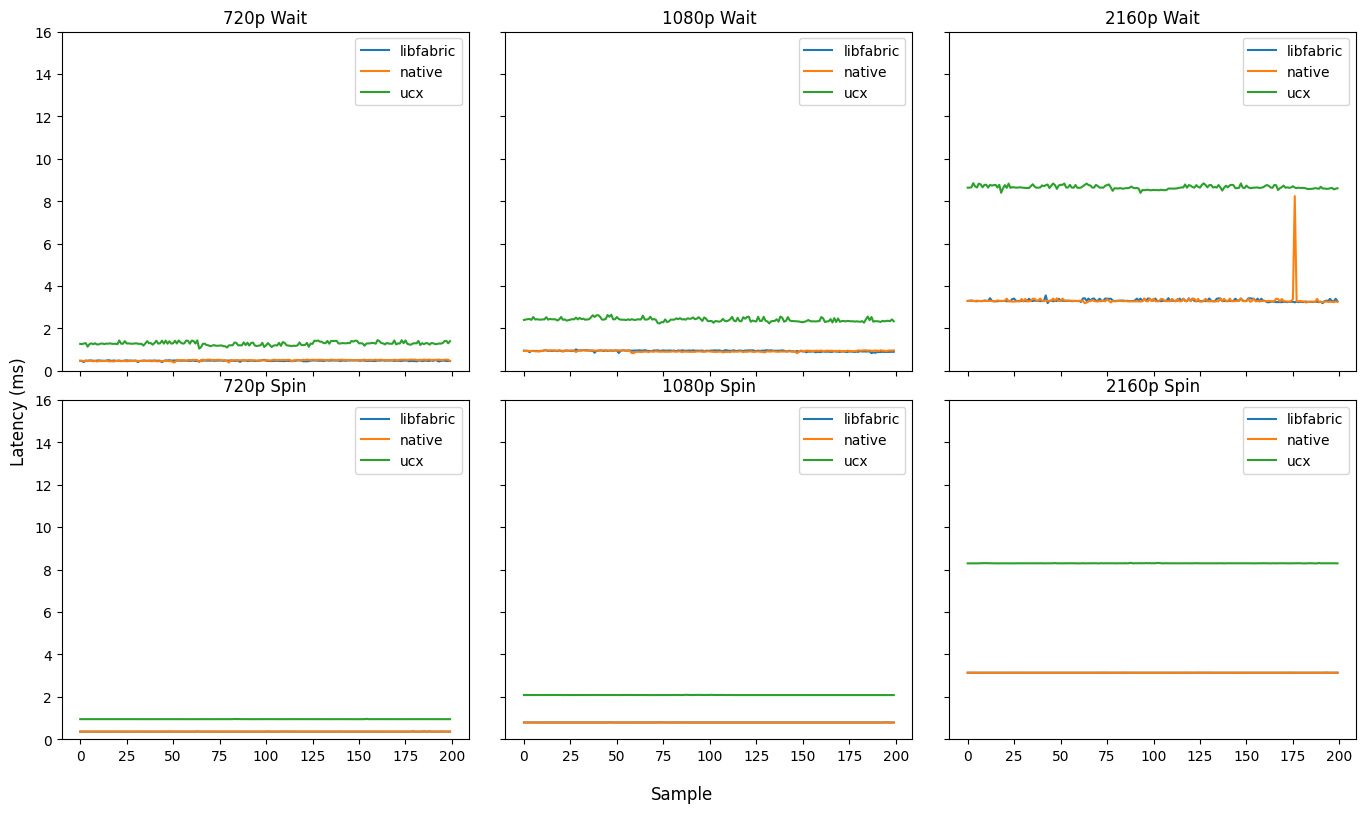

In [111]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for library in [Library.libfabric,  Library.native]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.d2d, Transport.verbs, TransferMode.reflect)]/2/1e6, label=f"{library.value}")
        axs[j][i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.d2d, Transport.none, TransferMode.reflect)]/2/1e6, label=f"ucx")
        axs[j][i].legend()

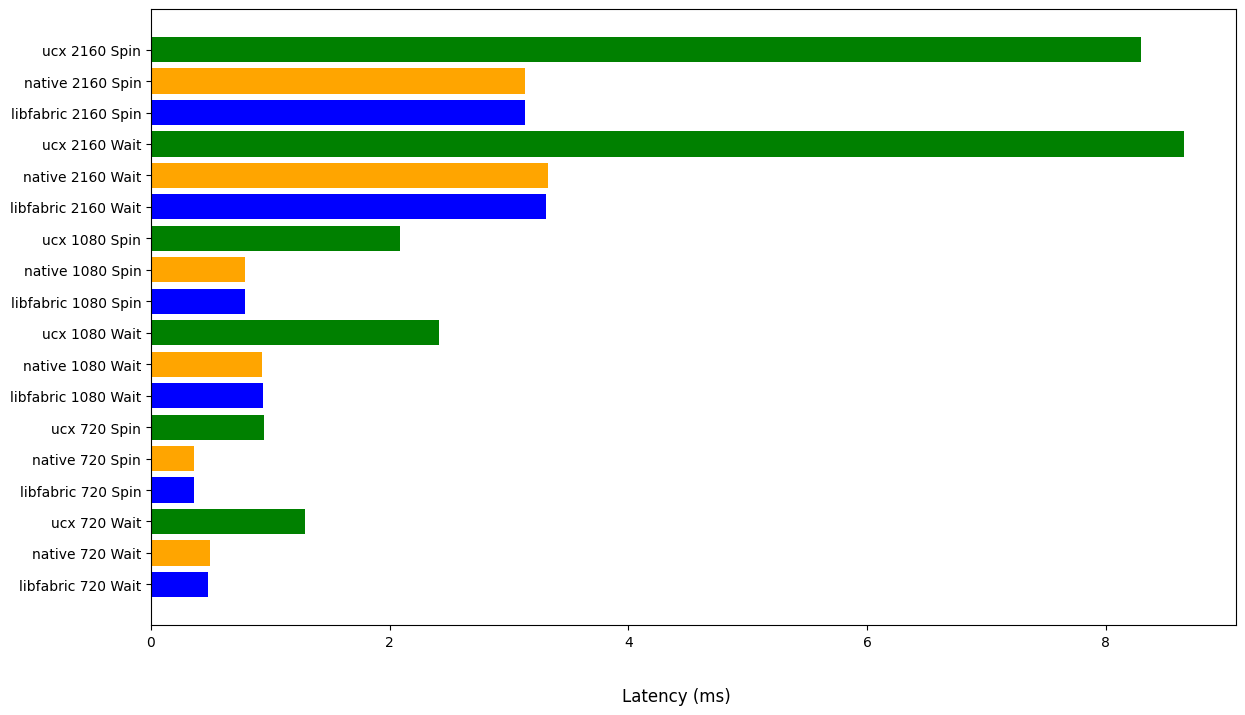

In [112]:
fig = plt.figure()
fig.supxlabel("Latency (ms)")

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        for library in [Library.libfabric, Library.native]:
            x = (f"{library.name} {format.value} {comp.value}")
            y=data[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.d2d, Transport.verbs, TransferMode.reflect)].mean()/2/1e6
            plt.barh(x,y, color="blue" if library==Library.libfabric else "orange")
        x = f"ucx {format.value} {comp.value}"
        y= data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.d2d, Transport.none, TransferMode.reflect)].mean()/2/1e6
        plt.barh(x,y, color="green")

In [113]:
data_columns=["format", "completion", "library"]
data_df = make_table(data, perf, columns=data_columns)
table= GT(data_df.sort(["format", "completion"]))

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["mean", "max", "std"]
    )
)

GT(_tbl_data=shape: (18, 7)
┌────────┬────────────┬───────────┬─────────┬─────────┬────────┬────────┐
│ format ┆ completion ┆ library   ┆ mean    ┆ max     ┆ std    ┆ usage  │
│ ---    ┆ ---        ┆ ---       ┆ ---     ┆ ---     ┆ ---    ┆ ---    │
│ enum   ┆ enum       ┆ enum      ┆ f64     ┆ f64     ┆ f64    ┆ f64    │
╞════════╪════════════╪═══════════╪═════════╪═════════╪════════╪════════╡
│ 720    ┆ Spin       ┆ libfabric ┆ 0.7229  ┆ 0.7566  ┆ 0.0049 ┆ 0.0477 │
│ 720    ┆ Spin       ┆ native    ┆ 0.7202  ┆ 0.7493  ┆ 0.0024 ┆ 0.0486 │
│ 720    ┆ Spin       ┆ ucx       ┆ 1.8981  ┆ 1.9295  ┆ 0.0032 ┆ 0.1162 │
│ 720    ┆ Wait       ┆ libfabric ┆ 0.9582  ┆ 1.0489  ┆ 0.0295 ┆ 0.0133 │
│ 720    ┆ Wait       ┆ native    ┆ 0.9965  ┆ 1.0778  ┆ 0.0557 ┆ 0.0129 │
│ …      ┆ …          ┆ …         ┆ …       ┆ …       ┆ …      ┆ …      │
│ 2160   ┆ Spin       ┆ native    ┆ 6.2737  ┆ 6.2837  ┆ 0.0015 ┆ 0.378  │
│ 2160   ┆ Spin       ┆ ucx       ┆ 16.5932 ┆ 16.6353 ┆ 0.0075 ┆ 0.9981 │
│ 2160   ┆ Wait       ┆ libfabric ┆ 6.6265  ┆ 7.1161  ┆ 0.111  ┆ 0.0135 │
│ 2160   ┆ Wait       ┆ native    ┆ 6.6577  ┆ 16.4761 ┆ 0.704  ┆ 0.0144 │
│ 2160   ┆ Wait       ┆ ucx       ┆ 17.316  ┆ 17.7009 ┆ 0.1673 ┆ 0.0115 │
└────────┴────────────┴───────────┴─────────┴─────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x79f9eb939090>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x79f9ec816e90>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'completion', 'library'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x79f9edf27090>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif

## Device to Host 2 Host to Device Inter-host

In [114]:
config = {"libraries":[Library.libfabric, Library.native],"tests": [Test.mxl_fabrics], "movements": [Movement.d2d, Movement.dh2hd], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}

# load data
data, perf = load_data(f"{data_dir}/dh2hd-interhost", timers_loader, **config)

### Comparison libfabric vs native for Device-to-Host-to-Host-to-Device transfers

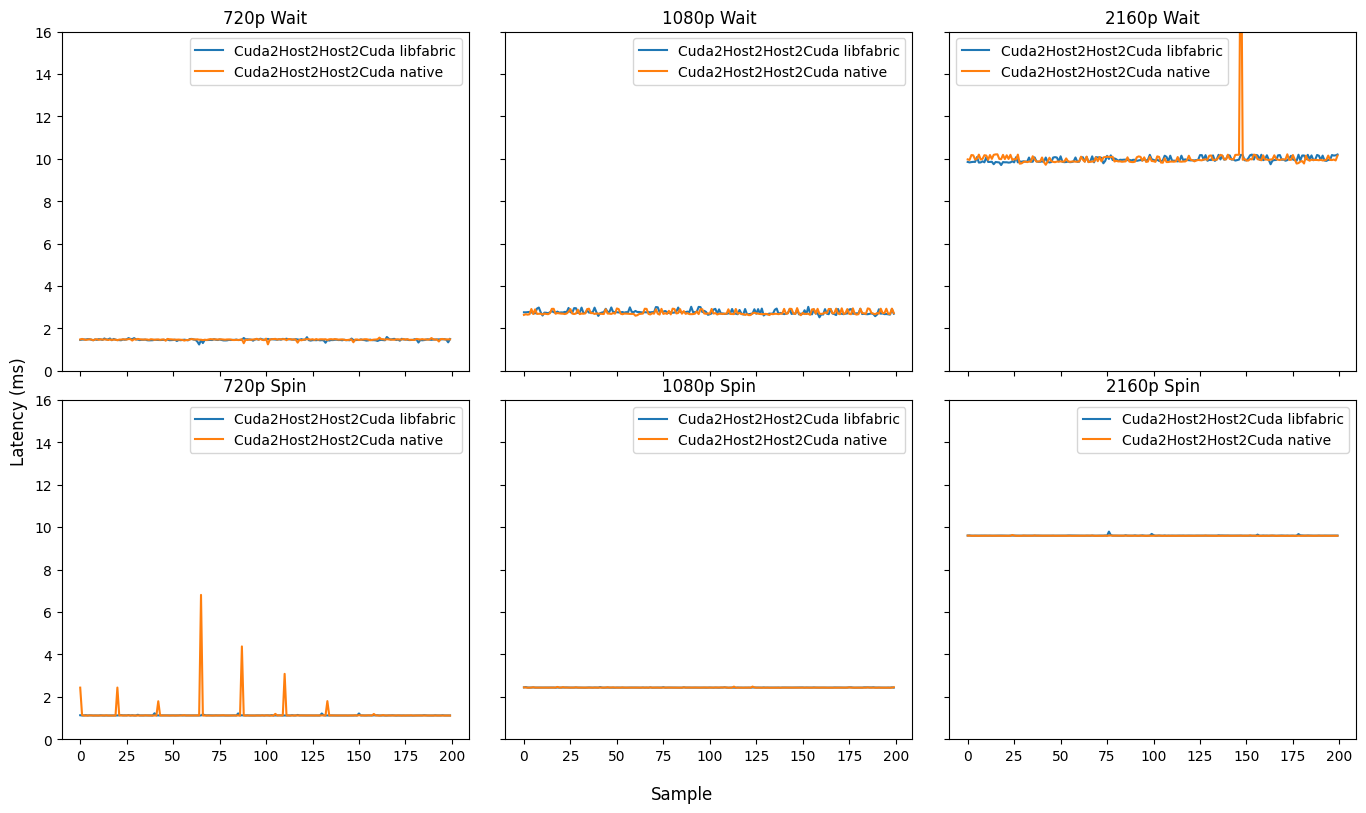

In [115]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for library in config["libraries"]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.dh2hd, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.value} {library.value}")
            axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using libfabric

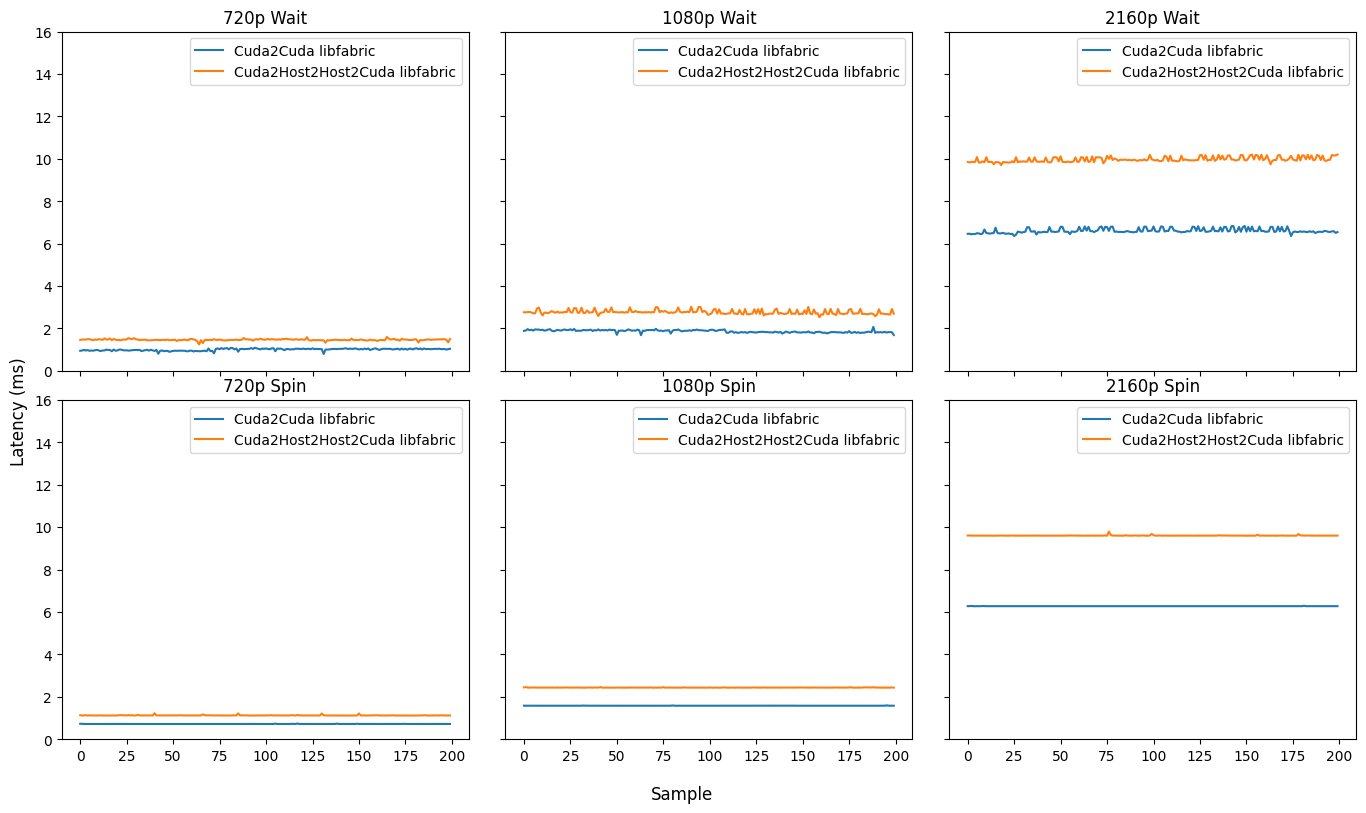

In [116]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

library = Library.libfabric

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in config["movements"]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.value} {library.value}")
            axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using native

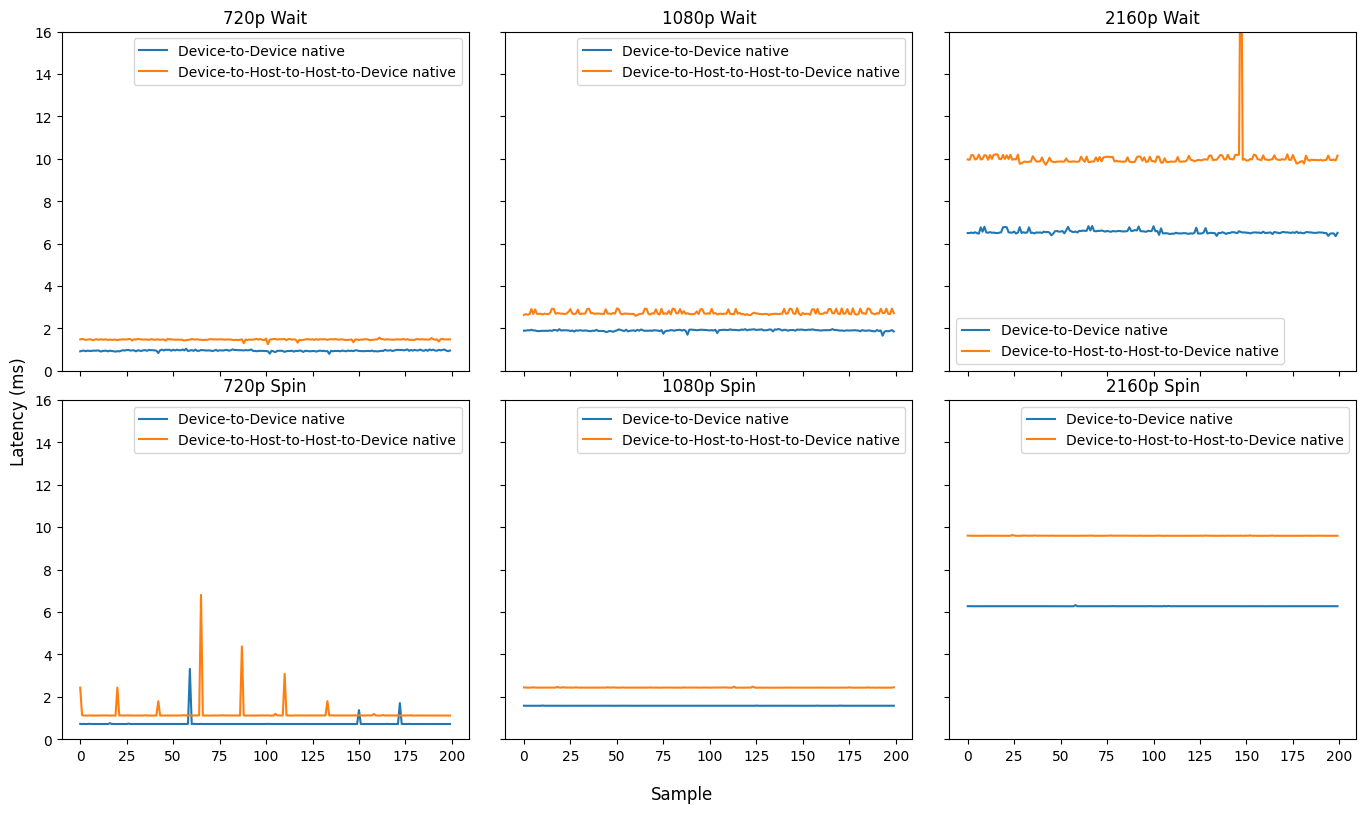

In [117]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

library = Library.native

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in config["movements"]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.to_study_name()} {library.value}")
            axs[j][i].legend()

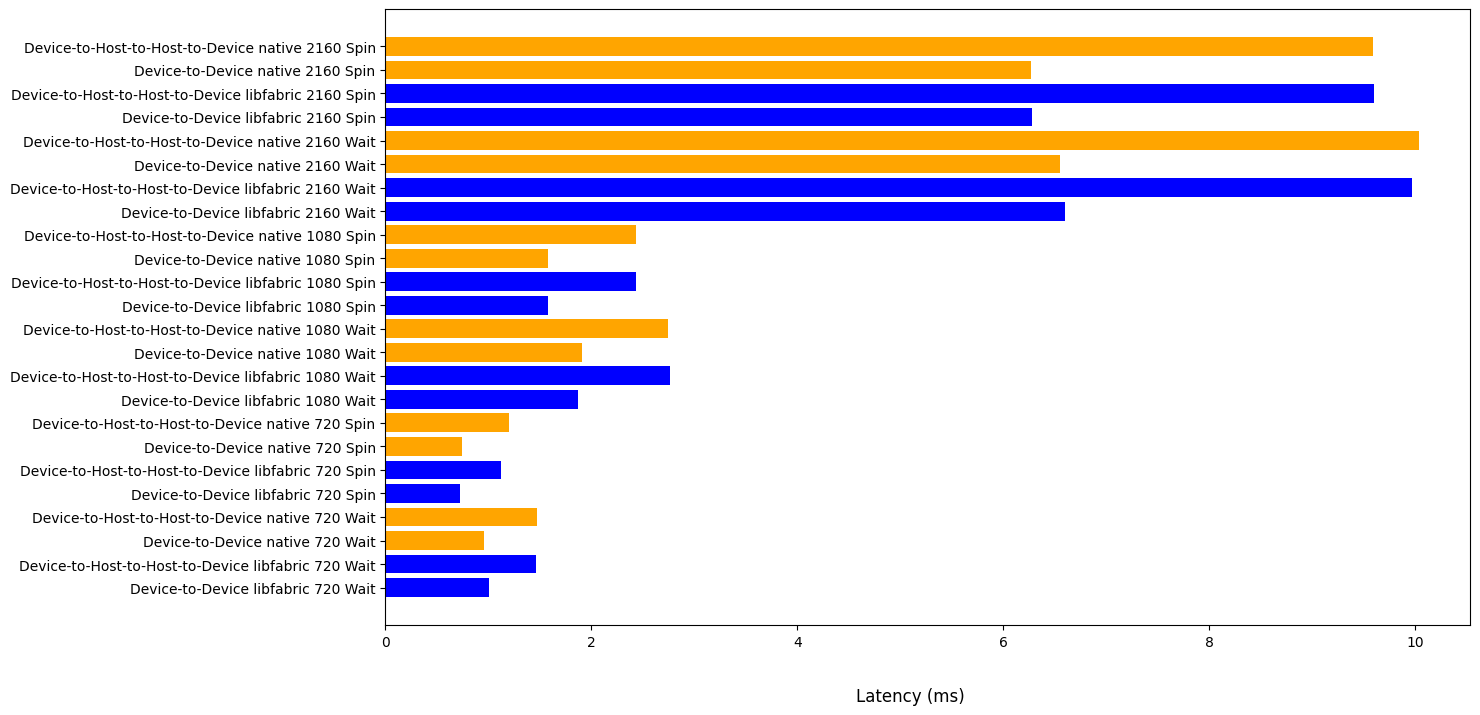

In [118]:
fig = plt.figure()
fig.supxlabel("Latency (ms)")

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        for library in config["libraries"]:
            for movement in config["movements"]:
                x = (f"{movement.to_study_name()} {library.name} {format.value} {comp.value}")
                y=data[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)].mean()/1e6
                plt.barh(x,y, color="blue" if library==Library.libfabric else "orange")

In [119]:
data_columns = ["format", "completion", "library", "movement"]
data_df = make_table(data, perf, columns=data_columns)
table = GT(data_df.sort(["format", "completion"]))

table
(
    table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["mean", "max", "std"]
    )
)


GT(_tbl_data=shape: (24, 8)
┌────────┬────────────┬───────────┬─────────────────────┬─────────┬─────────┬────────┬────────┐
│ format ┆ completion ┆ library   ┆ movement            ┆ mean    ┆ max     ┆ std    ┆ usage  │
│ ---    ┆ ---        ┆ ---       ┆ ---                 ┆ ---     ┆ ---     ┆ ---    ┆ ---    │
│ enum   ┆ enum       ┆ enum      ┆ enum                ┆ f64     ┆ f64     ┆ f64    ┆ f64    │
╞════════╪════════════╪═══════════╪═════════════════════╪═════════╪═════════╪════════╪════════╡
│ 720    ┆ Spin       ┆ libfabric ┆ Cuda2Cuda           ┆ 0.7221  ┆ 0.7442  ┆ 0.0029 ┆ 0.0476 │
│ 720    ┆ Spin       ┆ libfabric ┆ Cuda2Host2Host2Cuda ┆ 1.1266  ┆ 1.2276  ┆ 0.0147 ┆ 0.0749 │
│ 720    ┆ Spin       ┆ native    ┆ Cuda2Cuda           ┆ 0.7414  ┆ 3.3182  ┆ 0.2013 ┆ 0.05   │
│ 720    ┆ Spin       ┆ native    ┆ Cuda2Host2Host2Cuda ┆ 1.1968  ┆ 6.8069  ┆ 0.5014 ┆ 0.0774 │
│ 720    ┆ Wait       ┆ libfabric ┆ Cuda2Cuda           ┆ 1.004   ┆ 1.0911  ┆ 0.0498 ┆ 0.0111 │
│ …      ┆ …          ┆ …         ┆ …                   ┆ …       ┆ …       ┆ …      ┆ …      │
│ 2160   ┆ Spin       ┆ native    ┆ Cuda2Host2Host2Cuda ┆ 9.5959  ┆ 9.6291  ┆ 0.0042 ┆ 0.5766 │
│ 2160   ┆ Wait       ┆ libfabric ┆ Cuda2Cuda           ┆ 6.6042  ┆ 6.8332  ┆ 0.1106 ┆ 0.0119 │
│ 2160   ┆ Wait       ┆ libfabric ┆ Cuda2Host2Host2Cuda ┆ 9.9684  ┆ 10.2006 ┆ 0.1176 ┆ 0.1085 │
│ 2160   ┆ Wait       ┆ native    ┆ Cuda2Cuda           ┆ 6.5471  ┆ 6.8303  ┆ 0.084  ┆ 0.0119 │
│ 2160   ┆ Wait       ┆ native    ┆ Cuda2Host2Host2Cuda ┆ 10.0349 ┆ 22.6598 ┆ 0.9045 ┆ 0.1106 │
└────────┴────────────┴───────────┴─────────────────────┴─────────┴─────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x79f9e93f6510>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.default: 1>, column_label='movement', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x79f9e95b6750>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'completion', 'library', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x79f9ec236f10>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, categ

## Host to Device Intra-Host

In [120]:
config = {"libraries": [Library.libfabric], "movements": [Movement.h2d], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda, Test.ucx]}
data, perf = load_data(f"{data_dir}/h2d-intrahost", diff_loader, **config)

### Comparison libfabric vs native cuda for Host-to-Device transfers

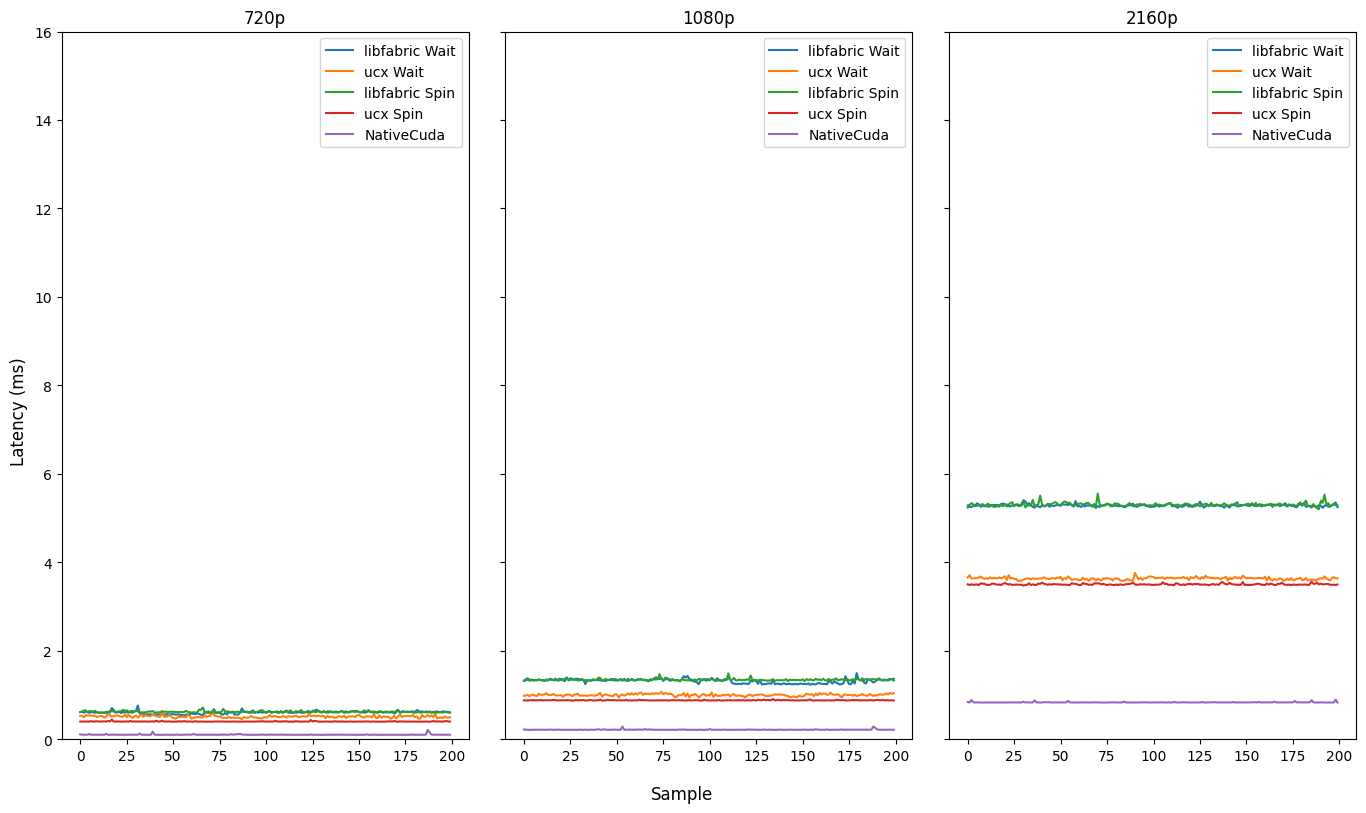

In [121]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric {comp.value}")
        axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.h2d, Transport.none, TransferMode.oneway)]/1e6, label=f"ucx {comp.value}")
    axs[i].plot(data[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.h2d, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

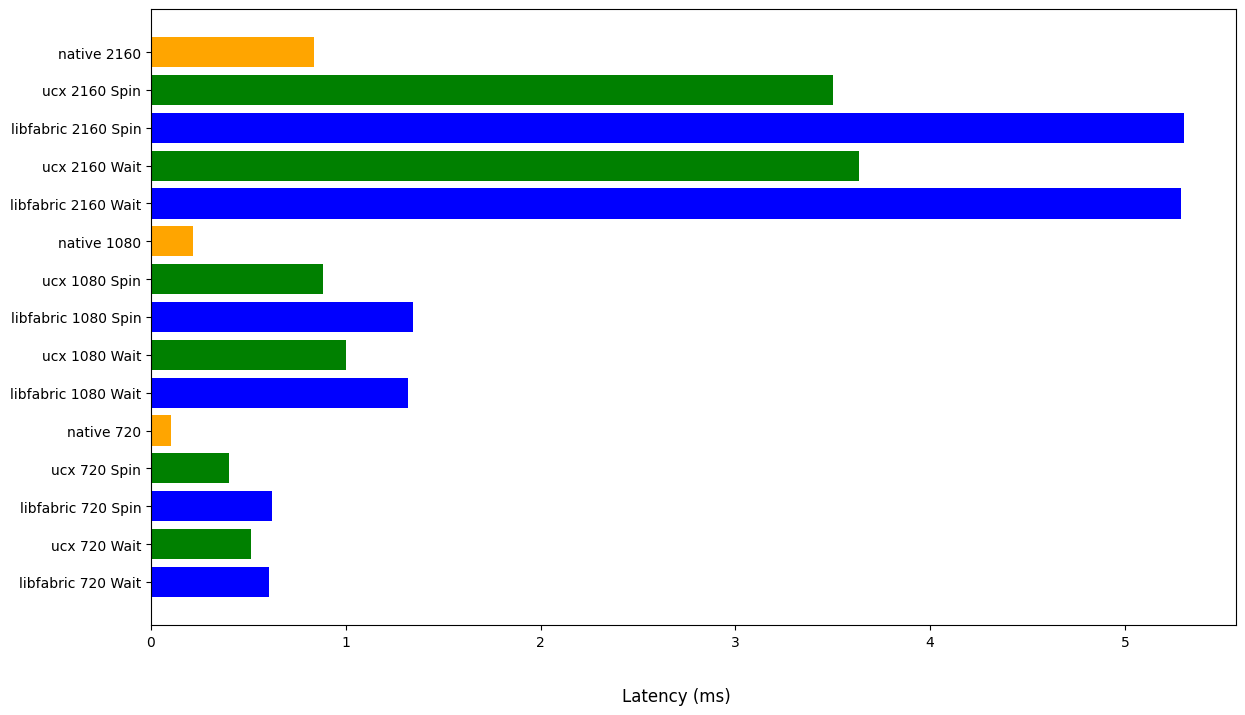

In [122]:
fig = plt.figure()
fig.supxlabel("Latency (ms)")

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        y = data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)].mean()/1e6
        plt.barh(f"libfabric {format.value} {comp.value}", y, color="blue")
        y = data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.h2d, Transport.none, TransferMode.oneway)].mean()/1e6
        plt.barh(f"ucx {format.value} {comp.value}", y, color="green")
    x = (f"native {format.value}")
    y=data[TestConfiguration(Library.native, format,Completion.none, Test.native_cuda, Movement.h2d, Transport.none, TransferMode.none)].mean()/1e6
    plt.barh(x,y, color="orange")

In [123]:
data_columns = ["library","format", "completion", "test"]
data_df = make_table(data, perf, columns=data_columns)
table = GT(data_df.sort(["format", "completion"]))

table
(
    table
    .tab_header(
        title="Host-to-Device transfer latency comparison",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["mean", "max", "std"]
    )
)

GT(_tbl_data=shape: (15, 8)
┌───────────┬────────┬────────────┬────────────┬────────┬────────┬────────┬────────┐
│ library   ┆ format ┆ completion ┆ test       ┆ mean   ┆ max    ┆ std    ┆ usage  │
│ ---       ┆ ---    ┆ ---        ┆ ---        ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ enum      ┆ enum   ┆ enum       ┆ enum       ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞═══════════╪════════╪════════════╪════════════╪════════╪════════╪════════╪════════╡
│ libfabric ┆ 720    ┆ Spin       ┆ MXLFabrics ┆ 0.6204 ┆ 0.7177 ┆ 0.0179 ┆ 0.0416 │
│ ucx       ┆ 720    ┆ Spin       ┆ UCX        ┆ 0.4022 ┆ 0.4466 ┆ 0.0057 ┆ 0.0301 │
│ libfabric ┆ 720    ┆ Wait       ┆ MXLFabrics ┆ 0.6071 ┆ 0.7636 ┆ 0.0306 ┆ 0.0416 │
│ ucx       ┆ 720    ┆ Wait       ┆ UCX        ┆ 0.5135 ┆ 0.6543 ┆ 0.0275 ┆ 0.011  │
│ native    ┆ 720    ┆            ┆ NativeCuda ┆ 0.1044 ┆ 0.213  ┆ 0.0107 ┆ 0.015  │
│ …         ┆ …      ┆ …          ┆ …          ┆ …      ┆ …      ┆ …      ┆ …      │
│ libfabric ┆ 2160   ┆ Spin       ┆ MXLFabrics ┆ 5.3045 ┆ 5.5527 ┆ 0.0408 ┆ 0.3249 │
│ ucx       ┆ 2160   ┆ Spin       ┆ UCX        ┆ 3.5028 ┆ 3.5623 ┆ 0.0149 ┆ 0.2143 │
│ libfabric ┆ 2160   ┆ Wait       ┆ MXLFabrics ┆ 5.2851 ┆ 5.4042 ┆ 0.028  ┆ 0.3199 │
│ ucx       ┆ 2160   ┆ Wait       ┆ UCX        ┆ 3.6347 ┆ 3.7625 ┆ 0.0283 ┆ 0.008  │
│ native    ┆ 2160   ┆            ┆ NativeCuda ┆ 0.835  ┆ 0.8959 ┆ 0.0087 ┆ 0.0579 │
└───────────┴────────┴────────────┴────────────┴────────┴────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x79fa0b1beed0>, _boxhead=Boxhead([ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='test', type=<ColInfoTypeEnum.default: 1>, column_label='test', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x79f9ec72a3d0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['library', 'format', 'completion', 'test'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x79f9ebb665d0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_

## Device to Host Intra-Host

In [124]:
config = {"libraries": [Library.libfabric], "movements": [Movement.d2h], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda, Test.ucx]}
data, perf = load_data(f"{data_dir}/d2h-intrahost", diff_loader, **config)

### Comparison libfabric vs native cuda for Device-to-Host transfers

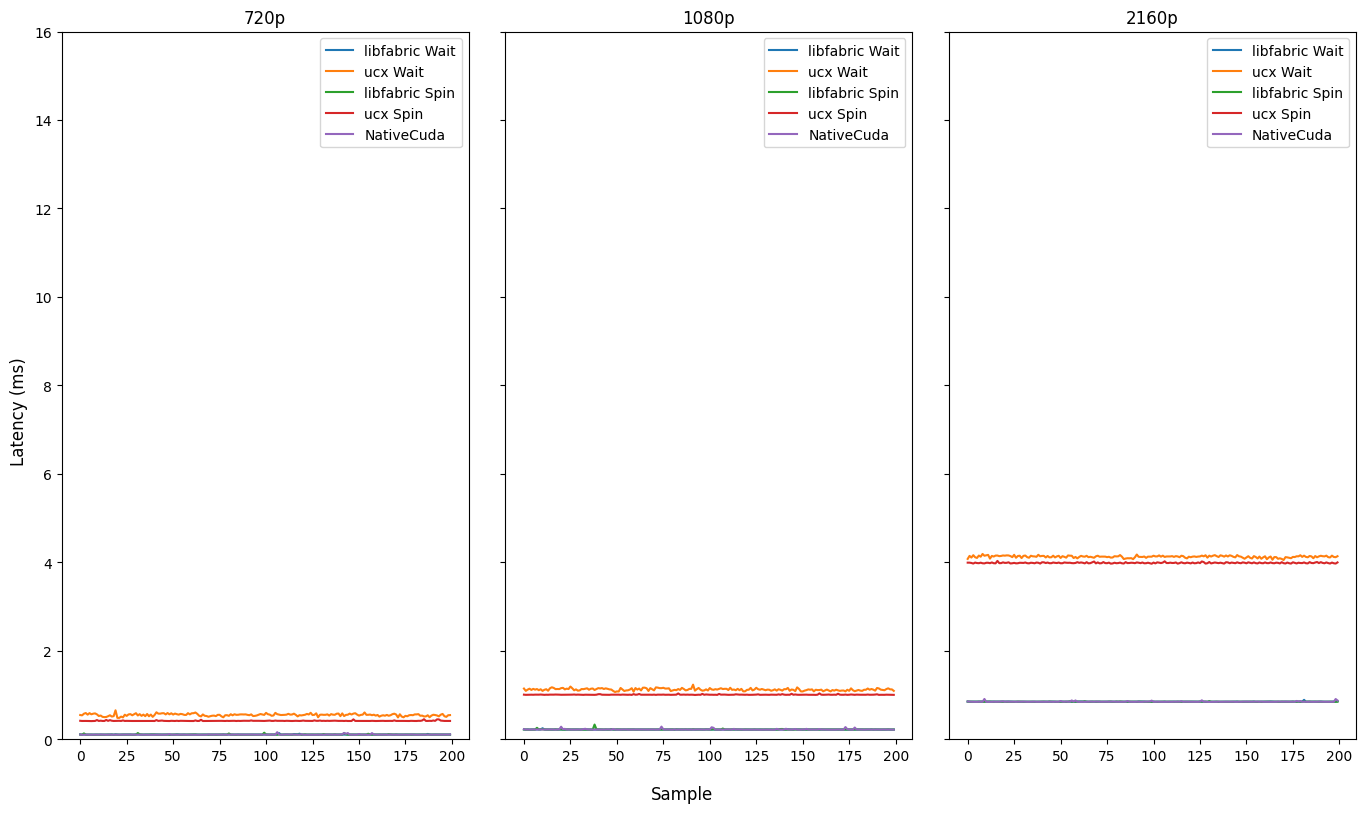

In [125]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:        
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.d2h, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric {comp.value}")
        axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.d2h, Transport.none, TransferMode.oneway)]/1e6, label=f"ucx {comp.value}")
    axs[i].plot(data[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.d2h, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

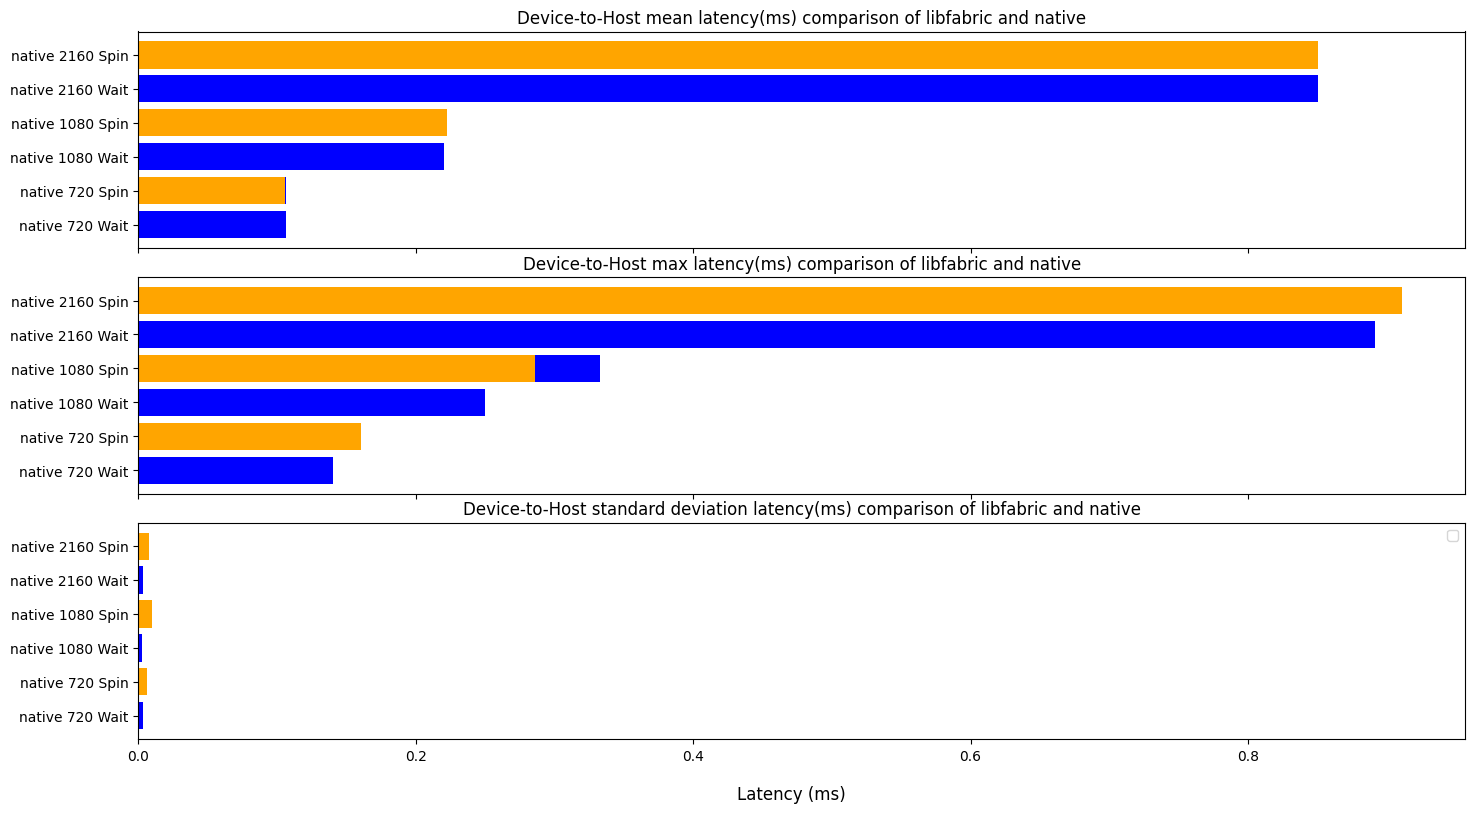

In [126]:
fig, axs = plt.subplots(nrows=3, ncols=1,sharex=True)
fig.supxlabel("Latency (ms)")
fig.tight_layout()

axs[0].set_title("Device-to-Host mean latency(ms) comparison of libfabric and native")
axs[1].set_title("Device-to-Host max latency(ms) comparison of libfabric and native")
axs[2].set_title("Device-to-Host standard deviation latency(ms) comparison of libfabric and native")

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        x = [(f"{library.name} {format.value} {comp.value}")]
        y=data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.d2h, Transport.shm, TransferMode.oneway)]/1e6
        ymean=y.mean()
        ymax=y.max()
        ystd=y.std()
        axs[0].barh(x,ymean, color="blue")
        axs[1].barh(x,ymax, color="blue")
        axs[2].barh(x,ystd, color="blue")
        plt.legend("")
    x = (f"native {format.value} {comp.value}")
    y = data[TestConfiguration(Library.native, format,Completion.none, Test.native_cuda, Movement.d2h, Transport.none, TransferMode.none)]/1e6
    ymean=y.mean()
    ymax=y.max()
    ystd=y.std()
    axs[0].barh(x,ymean, color="orange")
    axs[1].barh(x,ymax, color="orange")
    axs[2].barh(x,ystd, color="orange")

In [127]:
data_columns = ["library","format", "completion", "test"]
data_df = make_table(data, perf, columns=data_columns)
table = GT(data_df.sort(["format", "completion"]))

table
(
    table
    .tab_header(
        title="Device-to-N transfer latency comparison",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["mean", "max", "std"]
    )
)

GT(_tbl_data=shape: (15, 8)
┌───────────┬────────┬────────────┬────────────┬────────┬────────┬────────┬────────┐
│ library   ┆ format ┆ completion ┆ test       ┆ mean   ┆ max    ┆ std    ┆ usage  │
│ ---       ┆ ---    ┆ ---        ┆ ---        ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ enum      ┆ enum   ┆ enum       ┆ enum       ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞═══════════╪════════╪════════════╪════════════╪════════╪════════╪════════╪════════╡
│ libfabric ┆ 720    ┆ Spin       ┆ MXLFabrics ┆ 0.1066 ┆ 0.1491 ┆ 0.0058 ┆ 0.0174 │
│ ucx       ┆ 720    ┆ Spin       ┆ UCX        ┆ 0.4172 ┆ 0.4541 ┆ 0.0065 ┆ 0.037  │
│ libfabric ┆ 720    ┆ Wait       ┆ MXLFabrics ┆ 0.1068 ┆ 0.1402 ┆ 0.0034 ┆ 0.0109 │
│ ucx       ┆ 720    ┆ Wait       ┆ UCX        ┆ 0.5508 ┆ 0.6554 ┆ 0.0263 ┆ 0.01   │
│ native    ┆ 720    ┆            ┆ NativeCuda ┆ 0.1058 ┆ 0.1609 ┆ 0.0065 ┆ 0.0105 │
│ …         ┆ …      ┆ …          ┆ …          ┆ …      ┆ …      ┆ …      ┆ …      │
│ libfabric ┆ 2160   ┆ Spin       ┆ MXLFabrics ┆ 0.8496 ┆ 0.8624 ┆ 0.0018 ┆ 0.0582 │
│ ucx       ┆ 2160   ┆ Spin       ┆ UCX        ┆ 3.9876 ┆ 4.0324 ┆ 0.0105 ┆ 0.2479 │
│ libfabric ┆ 2160   ┆ Wait       ┆ MXLFabrics ┆ 0.8501 ┆ 0.8916 ┆ 0.0033 ┆ 0.0552 │
│ ucx       ┆ 2160   ┆ Wait       ┆ UCX        ┆ 4.1274 ┆ 4.1897 ┆ 0.0235 ┆ 0.0077 │
│ native    ┆ 2160   ┆            ┆ NativeCuda ┆ 0.8504 ┆ 0.9111 ┆ 0.0082 ┆ 0.0601 │
└───────────┴────────┴────────────┴────────────┴────────┴────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x79f9ebb1fad0>, _boxhead=Boxhead([ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='test', type=<ColInfoTypeEnum.default: 1>, column_label='test', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x79fa084689d0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['library', 'format', 'completion', 'test'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Device-to-N transfer latency comparison', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x79fa20f01810>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css

## Device to Device Intra-host Inter-GPU